# Öneri Sistemleri

Öneri sistemleri, kullanıcıların geçmiş tercihlerine dayanarak onlara ürünler önermek için kullanılır. Öneri sistemleri genel olarak aşağıdaki kategorilere ayrılır:

- **İçerik tabanlı (Content-based)**: Ürün özelliklerinin (ör. anahtar kelimeler, kategoriler) ve kullanıcı tercihlerinin benzerliğine dayanır.  
  Örneğin, bir kullanıcı Ürün A’yı beğendiyse, öneri sistemi benzer özelliklere sahip ürünleri önerir. Filmler üzerinden konuşursak, bu özellikler yapımcı, tür vb. olabilir. Genellikle bu yaklaşım, denetimli bir ikili sınıflandırma algoritması ile uygulanabilir.

- **İşbirlikçi filtreleme (Collaborative filtering)**: Benzerliği kullanıcı–ürün etkileşimlerinden (ör. puanlar, satın alma sayısı, beğeniler vb.) hesaplar.  
  Bu yöntem, benzer tercihlere sahip müşterileri bulur ve ardından bir müşteriye, onun henüz deneyimlemediği fakat benzer profildeki diğer müşteriler tarafından tercih edilen ürünleri önerir. Sistem, benzer film izleme alışkanlıklarına sahip kullanıcıların genel olarak benzer tercihlere sahip olduğu varsayımını yapar. Kullanıcının izlediklerine benzer videolar izleyen diğer kullanıcıları bulur, ardından bu kullanıcıların izlediği fakat ilk kullanıcının henüz izlemediği videoları önerir. Bu yaklaşımın 3 türü vardır: kullanıcı–kullanıcı işbirlikçi filtreleme, ürün–ürün işbirlikçi filtreleme ve matris çarpanlarına ayırma (matrix factorization).

- Daha yeni ve genellikle daha güçlü yaklaşımlar ise **Hibrit sistemlerdir (Hybrid systems)**.  
  Bu sistemler, yukarıda bahsedilen iki yöntemi birleştirir.

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/05-ML/06-Unsupervised-Learning/recommendation_systems.png" width=600>

Yukarıdaki diyagram, bir öneri sistemi oluşturmak için kullanılan farklı metodolojileri detaylı bir şekilde sınıflandırmaktadır.

Daha sonra örnek veri seti olarak kullanılacak olan `movieLens` bağlamında:
- İçerik benzerliğine (ör. tür, oyuncu kadrosu vb.) dayalı olarak farklı filmler önerebiliriz; bu durumda **ürün-içerik (item-content) filtreleme** uygulanır.
- Kullanıcı meta verilerini (ör. yaş, cinsiyet) karşılaştırarak, benzer kullanıcıların beğendiği ürünleri bir kullanıcıya önerebiliriz; bu durumda **kullanıcı-içerik (user-content) filtreleme** kullanılır. Ancak `movieLens` veri seti kullanıcı içerik verilerini içermediği için, yalnızca **ürün-ürün (item-item) işbirlikçi filtreleme** oluşturacağız.

**Bellek tabanlı (Memory-based) içerik filtreleme**

Bellek tabanlı yöntemlerde, veriden öğrenip tahmin yapan bir model yoktur. Bunun yerine, film önerileri için kullanılabilecek **önceden hesaplanmış bir benzerlik matrisi** oluşturulur.

## Veri toplama ve temizleme

Aşağıdaki satırları çalıştırarak gerekli veri kümelerini indirin. Ardından, veri kümelerini üç farklı pandas DataFrame'e (`movies`, `tags` ve `ratings`) yükleyin.

In [1]:
!curl https://d32aokrjazspmn.cloudfront.net/materials/movie_ratings.csv > data/movies.csv
!curl https://d32aokrjazspmn.cloudfront.net/materials/movie_tags.csv > data/tags.csv
!curl https://d32aokrjazspmn.cloudfront.net/materials/movie_titles.csv > data/ratings.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 2425k  100 2425k    0     0   306k      0  0:00:07  0:00:07 --:--:--  365k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  115k  100  115k    0     0   139k      0 --:--:-- --:--:-- --:--:--  138k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  482k  100  482k    0     0   263k      0  0:00:01  0:00:01 --:--:--  263k


In [4]:
import pandas as pd

# Dosya isimleri indirilirken ters kaydedildiği için onları doğru değişkenlere atıyoruz:
movies = pd.read_csv('data/ratings.csv')  # Aslında içinde film isimleri ve türleri var
ratings = pd.read_csv('data/movies.csv')  # Aslında içinde kullanıcı puanları var
tags = pd.read_csv('data/tags.csv')       # Bu zaten doğruydu

__Farklı film türlerini ayıran ‘|’ işaretini kaldırın ve boşluk ile değiştirin.__

In [5]:
# 'genres' sütunundaki '|' işaretlerini boşlukla değiştiriyoruz
movies['genres'] = movies['genres'].str.replace('|', ' ', regex=False)

__`movies` veri çerçevesini filtreleyerek, yalnızca puan almış filmleri elde edin.__

In [6]:
# ratings tablosundaki benzersiz film ID'lerini alıyoruz
puanlanan_film_idleri = ratings['movieId'].unique()

# movies tablosunu, sadece puanlanan filmler kalacak şekilde filtreliyoruz
movies = movies[movies['movieId'].isin(puanlanan_film_idleri)]

### 🧪 Kodunu Test Et

In [7]:
from nbresult import ChallengeResult

result = ChallengeResult(
    'datasets',
    movies_shape=movies.shape,
    tags_shape=tags.shape,
    ratings_shape=ratings.shape,
    genres_cleaned=movies['genres'].str.find('|') >= 0
)

result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/macos/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/macos/Desktop/S17D3-S-data-movie-recommendation/tests
plugins: dash-4.0.0, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 4 items

test_datasets.py::TestDatasets::test_genres_are_cleaned PASSED           [ 25%]
test_datasets.py::TestDatasets::test_movies_shape PASSED                 [ 50%]
test_datasets.py::TestDatasets::test_ratings_shape PASSED                [ 75%]
test_datasets.py::TestDatasets::test_tags_shape PASSED                   [100%]

============================== 4 passed in 0.92s ===============================


💯 You can commit your code:

git add tests/datasets.pickle

git commit -m 'Completed datasets step'

git push origin master



## Özellik Mühendisliği

Bir film hakkında sahip olduğumuz **tüm metin verisi bilgilerini**, yani türü ve etiketleri birleştiren `metadata` adlı yeni bir özellik oluşturacağız.

__`movies` ve `tags` DataFrame'lerini birleştirin.__

In [8]:
# movies ve tags tablolarını movieId ortak sütunu üzerinden birleştiriyoruz
movie_tags = pd.merge(movies, tags, on='movieId', how='left')

**`metadata` sütununu içeren yeni bir `merged_df` veri çerçevesi oluşturun. Bu sütun, hem etiketlerin (tags) hem de türlerin (genres) birleştirilmiş hâlinden oluşmalıdır.**

Bunun için:
- Önce **etiketleri (tags)** film bazında birleştirin.
- Ardından bu birleştirilmiş etiketleri **genres** sütunu ile birleştirin.

Örneğin *Toy Story* filminin `metadata` sütunu şu şekilde olmalıdır:  
`pixar pixar fun Adventure Animation Children Comedy Fantasy`

👉 `merged_df` en azından şu sütunları içermelidir: `movieId`, `title` ve `metadata`.

In [9]:
# 1. Aynı filme ait birden fazla etiket (tag) varsa, onları aralarında boşluk bırakarak birleştiriyoruz
# title ve genres sütunları kaybolmasın diye onları da gruplamaya dahil ediyoruz
merged_df = movie_tags.groupby(['movieId', 'title', 'genres'])['tag'].apply(lambda x: ' '.join(x.dropna())).reset_index()

# 2. 'metadata' adlı yeni sütunu oluşturuyoruz: birleştirilmiş etiketler (tag) + boşluk + türler (genres)
merged_df['metadata'] = merged_df['tag'] + " " + merged_df['genres']

# Eğer filmin hiç etiketi yoksa başta oluşabilecek fazladan boşluğu temizliyoruz
merged_df['metadata'] = merged_df['metadata'].str.strip()

# 3. Yönergenin bizden istediği minimum sütunları seçip tabloyu sadeleştiriyoruz
merged_df = merged_df[['movieId', 'title', 'metadata']]

### 🧪 Kodunu Test Et

In [10]:
from nbresult import ChallengeResult
import numpy as np

result = ChallengeResult(
    'feature_engineering',
    unique_movies=np.all(merged_df[['movieId']].value_counts() > 1),
    metadata=merged_df[merged_df['title'] == 'Copycat (1995)'],
    merged_df_rows=merged_df.shape[0]
)

result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/macos/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/macos/Desktop/S17D3-S-data-movie-recommendation/tests
plugins: dash-4.0.0, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 4 items

test_feature_engineering.py::TestFeatureEngineering::test_merged_df_rows PASSED [ 25%]
test_feature_engineering.py::TestFeatureEngineering::test_metadata_has_genres PASSED [ 50%]
test_feature_engineering.py::TestFeatureEngineering::test_metadata_has_tags PASSED [ 75%]
test_feature_engineering.py::TestFeatureEngineering::test_unicity_of_movies PASSED [100%]

============================== 4 passed in 0.91s ===============================


💯 You can commit your code:

git add tests/feature_engineering.pickle

git commit -m 'Completed feature_engineering step'

git push origin master



## Metadata’dan içerik gizil (latent) matrisi oluşturma

### Count Vectorizer

Bir sonraki adımda, metadata metinlerini vektörlere dönüştürmemiz gerekiyor; böylece bunları makine öğrenmesi algoritmalarına verebiliriz. Makine öğrenmesi modelleri metin verisini doğrudan anlayamaz, bu yüzden kodlamamız gerekir.

Bu amaçla [`CountVectorizer`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) kullanarak `metadata` sütununu encode edeceğiz.

Count dönüşümü sonucunda elde ettiğiniz vektörlerden oluşan yeni bir `count_df` veri çerçevesi oluşturun.  
Her satır, ilgili filme ait **frekans vektörünü** temsil edecektir.

In [11]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# CountVectorizer nesnesini oluşturuyoruz
count = CountVectorizer()

# 'metadata' sütunundaki metinleri öğrenip sayısal bir matrise çeviriyoruz
count_matrix = count.fit_transform(merged_df['metadata'])

# Sonucu 'count_df' adında bir pandas DataFrame'ine dönüştürüyoruz
# Sütun isimleri olarak algoritmamızın yakaladığı benzersiz kelimeleri atıyoruz
count_df = pd.DataFrame(count_matrix.toarray(), columns=count.get_feature_names_out(), index=merged_df['movieId'])

print(f"Count Matrisi Boyutu: {count_df.shape}")

Count Matrisi Boyutu: (9724, 1746)


### Boyut indirgeme

Her bir filmin metadata’sı yaklaşık **1675 uzunluğunda bir vektöre** dönüştürüldü!

Önceki derslerde gördüğümüz gibi, veriyi (filmleri) çok fazla bilgi kaybı olmadan temsil edebilmek için **boyut indirgeme** yöntemleri uygulayabiliriz. **Truncated Singular Value Decomposition (SVD)**, boyut indirgeme için kullanılan başka bir gelişmiş araçtır.

PCA’nın aksine, bu yöntem **tekil değer ayrışımını (SVD) hesaplamadan önce veriyi merkezlemez**. Bu da onun **seyrek (sparse) matrislerle verimli şekilde çalışabilmesini** sağlar. Özellikle terim sayım / frekans matrisleri üzerinde iyi çalışır. Bu bağlamda, **Latent Semantic Analysis (LSA)** olarak da bilinir.

Scikit-Learn’deki [`TruncatedSVD`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html) sınıfına göz atabilirsiniz; prensip olarak PCA ile aynıdır.

__👉 **Count matrinizin boyutunu azaltmak için (örneğin 25 feature olacak şekilde) Truncated SVD uygulayın.**__


In [12]:
from sklearn.decomposition import TruncatedSVD

# 25 bileşenli (özellikli) bir TruncatedSVD modeli oluşturuyoruz
svd = TruncatedSVD(n_components=25, random_state=42)

# Count matrisimizi bu modele verip 25 boyuta indirgiyoruz
# İşlemi hızlı yapması için count_matrix'in orijinal (sparse) halini kullanıyoruz
latent_matrix = svd.fit_transform(count_matrix)

print(f"İndirgenmiş Matris Boyutu: {latent_matrix.shape}")

İndirgenmiş Matris Boyutu: (9724, 25)


👉 **Toplam açıklanan varyans oranını bileşen sayısının bir fonksiyonu olarak grafiğe çizin.**

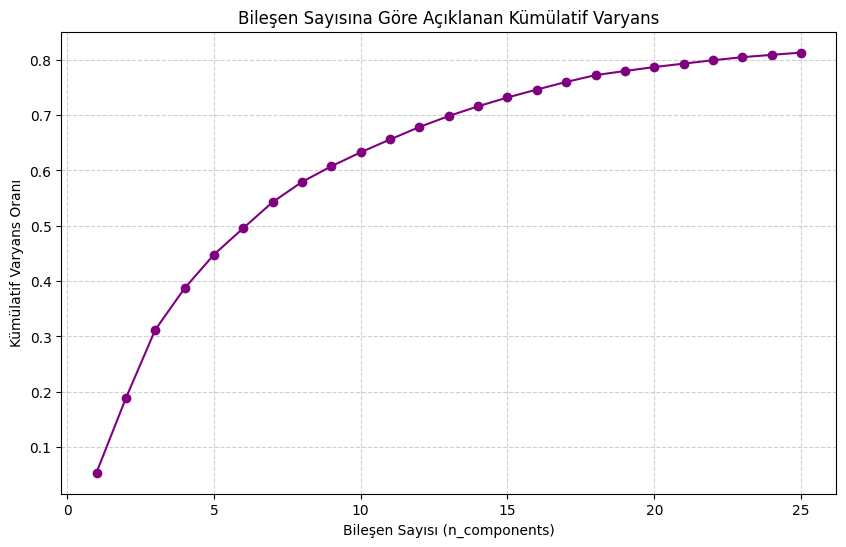

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Her bileşenin açıkladığı varyansın kümülatif toplamını hesaplıyoruz
kümülatif_varyans = np.cumsum(svd.explained_variance_ratio_)

# Grafiği çizdiriyoruz
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(kümülatif_varyans) + 1), kümülatif_varyans, marker='o', color='purple')

plt.title('Bileşen Sayısına Göre Açıklanan Kümülatif Varyans')
plt.xlabel('Bileşen Sayısı (n_components)')
plt.ylabel('Kümülatif Varyans Oranı')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

Sadece ilk 25 bileşenle (başlangıçta yaklaşık 1700 olan) varyansın **%80'inden fazlasını** açıklayabildiğimizi görüyoruz, bu da çalışma amaçlarımız için yeterlidir.

👉 **Bu matrisin 25 bileşenini, filmlerin başlıklarına göre indekslenmiş yeni bir `latent_df` veri çerçevesine kaydedin.**

In [14]:
# SVD'den dönen 25 boyutlu numpy dizisini pandas DataFrame'ine çeviriyoruz.
# Satır indekslerine (index) de filmlerin isimlerini atıyoruz ki
# "Toy Story" dediğimizde o filmin 25 sayılık DNA'sına (vektörüne) anında ulaşabilelim.
latent_df = pd.DataFrame(latent_matrix, index=merged_df['title'])

# Boyutunu ve ilk birkaç satırını kontrol edelim
print(f"Latent DataFrame Boyutu: {latent_df.shape}")
latent_df.head()

Latent DataFrame Boyutu: (9724, 25)


,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
title,,,,,,,,,,,,,,,,,,,,,
Toy Story (1995),0.906692,0.970036,-0.641471,-0.496960,0.916133,0.981349,-0.730853,0.425908,0.067736,-0.213435,...,-0.085086,-0.106250,-0.208171,0.018200,0.003569,-0.037879,-0.075628,-0.007356,-0.037004,-0.000095
Jumanji (1995),0.412862,0.161880,-0.589252,-0.697596,1.038237,1.269791,-0.500754,0.380975,0.386512,0.337164,...,0.409268,0.399669,-0.213370,-0.017983,0.009880,-0.013624,-0.090157,-0.023543,-0.013727,0.002388
Grumpier Old Men (1995),0.765446,0.916198,0.122466,0.017971,-0.282143,0.207786,0.653589,0.063256,-0.031728,0.003956,...,-0.009017,-0.010493,-0.061513,0.004673,-0.004105,0.005239,0.004729,0.005190,-0.002125,-0.000184
Waiting to Exhale (1995),1.413515,0.502954,0.641908,-0.224913,-0.260731,0.089353,0.437789,-0.029137,-0.023579,-0.003618,...,0.018886,-0.047970,-0.075586,0.007851,-0.012691,-0.001288,0.006809,0.005472,0.002289,-0.000609
Father of the Bride Part II (1995),0.523546,0.780180,-0.056380,0.187794,-0.098299,-0.146546,-0.155238,-0.109085,-0.106509,0.029023,...,-0.017587,-0.021179,-0.006054,0.006052,-0.004731,0.011703,0.004126,0.012422,-0.015377,-0.000777


### 🧪 Kodunu Test Et

In [15]:
from nbresult import ChallengeResult

result =  ChallengeResult(
    'metadata',
    counter_shape=count_df.shape,
    latent_shape=latent_df.shape
)

result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/macos/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/macos/Desktop/S17D3-S-data-movie-recommendation/tests
plugins: dash-4.0.0, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 3 items

test_metadata.py::TestMetadata::test_counter_columns PASSED              [ 33%]
test_metadata.py::TestMetadata::test_counter_rows PASSED                 [ 66%]
test_metadata.py::TestMetadata::test_features_number PASSED              [100%]

============================== 3 passed in 0.04s ===============================


💯 You can commit your code:

git add tests/metadata.pickle

git commit -m 'Completed metadata step'

git push origin master



## Kullanıcı Derecelendirmelerinden Latent Matris Oluşturma

Meta veriler dışında, bir başka değerli bilgi kaynağımız daha var: **kullanıcı derecelendirmeleri**. 

Bir öneri sistemi, kullanıcı derecelendirmelerine dayanarak benzer bir film önerebilir (öğeden öğeye işbirliğine dayalı filtreleme).

👉 **Aşağıdaki veri setini, filmleri satırlara, `userId`'leri sütunlara yerleştirecek şekilde hazırlıyoruz.**

In [16]:
# Merge
ratings1 = pd.merge(movies[['movieId']], ratings, on="movieId", how="right")
# Pivot
ratings2 = ratings1.pivot(index = 'movieId', columns ='userId', values = 'rating').fillna(0)
display(ratings2.head())
ratings2.shape

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
movieId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,0.0,0.0,4.0,0.0,4.5,0.0,0.0,0.0,...,4.0,0.0,4.0,3.0,4.0,2.5,4.0,2.5,3.0,5.0
2,0.0,0.0,0.0,0.0,0.0,4.0,0.0,4.0,0.0,0.0,...,0.0,4.0,0.0,5.0,3.5,0.0,0.0,2.0,0.0,0.0
3,4.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0


(9724, 610)

Kullanıcıların puanlarını 9724 uzunluğunda vektörler olarak içeren bir veri kümesi oluşturduk.

👉**Yine, ilk 200 bileşeni saklamak için `ratings2` veri çerçevesine SVD uygulayacağız. Bu veri çerçevesine `latent_df_2` adını verin.**

In [18]:
from sklearn.decomposition import TruncatedSVD

# 200 bileşenli (n_components=200) bir SVD modeli oluşturuyoruz
svd_200 = TruncatedSVD(n_components=200, random_state=42)

# Kullanıcı puanlarını içeren ratings2 matrisimizi 200 boyuta indirgiyoruz
latent_matrix_2 = svd_200.fit_transform(ratings2)

# İleride filmleri ID numaraları (1, 2, 3...) yerine isimleriyle (Toy Story...) bulabilmek için
# ratings2'nin indeksindeki ID'leri, movies tablosundaki title'lar ile eşleştiriyoruz
film_isimleri = movies.set_index('movieId').loc[ratings2.index, 'title']

# latent_df_2 adında yeni DataFrame'imizi oluşturuyoruz
latent_df_2 = pd.DataFrame(latent_matrix_2, index=film_isimleri)

print(f"İşbirlikçi Filtreleme Latent Matrisi Boyutu: {latent_df_2.shape}")
latent_df_2.head()

İşbirlikçi Filtreleme Latent Matrisi Boyutu: (9724, 200)


,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
title,,,,,,,,,,,,,,,,,,,,,
Toy Story (1995),37.649828,-6.380094,-14.994617,-0.286947,1.887147,-4.790050,-8.807629,-2.198637,-1.153304,-1.387562,...,1.509259,2.571558,1.079884,-1.489578,1.162201,-0.635675,0.914679,-0.016347,0.754628,-2.552653
Jumanji (1995),20.596193,-0.477880,-10.865916,8.635795,3.072411,0.517149,-4.359215,-3.821408,3.394117,-0.236474,...,0.741599,-0.827772,0.439950,1.747872,0.308577,1.728965,0.808715,0.755086,-1.051243,1.672944
Grumpier Old Men (1995),8.504182,-5.714924,-3.441693,6.382810,-0.024162,0.783432,1.423027,-0.542292,-3.270655,-1.897238,...,0.261826,-0.553680,-0.386709,0.085206,-0.116957,-0.844441,0.335339,-0.345159,1.245748,0.182475
Waiting to Exhale (1995),0.465720,-0.828101,-0.954583,0.239080,0.735695,0.877414,-0.214720,-0.527368,-0.079467,-0.015616,...,-0.063262,0.347930,0.193935,0.054893,-0.171441,0.137140,-0.180395,0.195418,0.011186,0.740383
Father of the Bride Part II (1995),6.071045,-2.673536,-4.698195,4.415807,3.714221,1.673627,-1.297653,-1.308023,-1.325734,-1.229592,...,-0.141982,-0.253920,-0.206540,0.256493,0.425539,-0.030499,1.036760,-1.443857,0.583250,0.836855


**👉 Film Adına Göre Yeniden Dizin Oluştur.**

In [19]:
# ratings2 tablosundaki movieId'leri, movies tablosundaki film isimleriyle eşleştiriyoruz
latent_df_2.index = movies.set_index('movieId').loc[ratings2.index, 'title']

In [20]:
latent_df_2.shape

(9724, 200)

### 🧪 Kodunu Test Et

In [21]:
from nbresult import ChallengeResult

result = ChallengeResult('ratings', latent_shape=latent_df_2.shape)

result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/macos/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/macos/Desktop/S17D3-S-data-movie-recommendation/tests
plugins: dash-4.0.0, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_ratings.py::TestRatings::test_latent_shape PASSED                   [100%]

============================== 1 passed in 0.02s ===============================


💯 You can commit your code:

git add tests/ratings.pickle

git commit -m 'Completed ratings step'

git push origin master



## İçerik ve İşbirlikçi (Collaborative) Matrislerde Kosinüs Benzerliği Uygulama

Sonraki adımda, oluşturduğumuz filtreleme yöntemlerine dayanarak **“Toy Story” filmine en çok benzeyen ilk $N$ filmi** bulmak için bir benzerlik ölçüsü kullanacağız. Kullanabileceğimiz benzerlik ölçülerinden biri **Kosinüs Benzerliği**dir. Scikit-learn’de bu işlem için [`cosine_similarity`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.cosine_similarity.html) fonksiyonu bulunur.

👉 **Örnek bir film (“Toy Story”) için hem içerik (metadata) hem de işbirlikçi (puanlar) latent matrislerine karşı kosinüs benzerliğini hesaplayın.**

In [22]:
from sklearn.metrics.pairwise import cosine_similarity

# Hedef filmimizi veri setindeki tam adıyla tanımlıyoruz
hedef_film = 'Toy Story (1995)'

# Toy Story'nin her iki matristeki 25 ve 200 boyutlu sayısal dizilerini (vektörlerini) alıyoruz
# kosinüs benzerliği formülü 2 boyutlu dizi beklediği için reshape(1, -1) kullanıyoruz
v_content = latent_df.loc[hedef_film].values.reshape(1, -1)
v_collab = latent_df_2.loc[hedef_film].values.reshape(1, -1)

# Toy Story vektörünü, veri setindeki TÜM DİĞER filmlerin vektörleriyle karşılaştırıyoruz
content_similarity = cosine_similarity(latent_df, v_content)
collaborative_similarity = cosine_similarity(latent_df_2, v_collab)

Ayrıca, içerik ve işbirliğine dayalı filtrelemenin benzerlik ortalamasını alan bir hibrit filtre de oluşturabiliriz. 

`hybrid_similarity = (content_similarity + collaborative_similarity) / 2`

__İçerik ve işbirliğine dayalı filtrelemenin benzerlik ortalamasını hesaplayın.__

In [23]:
# İçerik ve İşbirlikçi filtreleme skorlarının ortalamasını alıyoruz
hybrid_similarity = (content_similarity + collaborative_similarity) / 2.0

__Toy Story ile nihai benzerlikleri içeren bir dataframe oluşturun.__

In [24]:
import pandas as pd

# Benzerlik skorlarını içeren DataFrame'i oluşturuyoruz
sim_df = pd.DataFrame({
    'content': content_similarity.flatten(),
    'collaborative': collaborative_similarity.flatten(),
    'hybrid': hybrid_similarity.flatten()
}, index=latent_df.index) # Satır isimleri filmlerin adları olacak

__Data Frame'inizi işbirliğine dayalı benzerlik açısından en benzer olanlara göre sıralayın.__

In [25]:
# İşbirlikçi modele göre en yüksekten en düşüğe sıralayıp ilk 10'u getiriyoruz
print("--- İŞBİRLİKÇİ (COLLABORATIVE) ÖNERİLER ---")
display(sim_df.sort_values(by='collaborative', ascending=False).head(10))

--- İŞBİRLİKÇİ (COLLABORATIVE) ÖNERİLER ---


,content,collaborative,hybrid
title,,,
Toy Story (1995),1.000000,1.000000,1.000000
Toy Story 2 (1999),0.946816,0.642173,0.794494
Independence Day (a.k.a. ID4) (1996),0.198096,0.625355,0.411725
Jurassic Park (1993),0.198986,0.611037,0.405012
Mission: Impossible (1996),0.220889,0.603415,0.412152
Star Wars: Episode IV - A New Hope (1977),0.093940,0.591968,0.342954
Shrek (2001),0.912464,0.587650,0.750057
"Lion King, The (1994)",0.526982,0.583535,0.555259
Star Wars: Episode VI - Return of the Jedi (1983),0.191315,0.579852,0.385584


Elbette Toy Story'yi en benzer film olarak görmelisiniz (her sütun için benzerlik 1).

__Content ve hybrid türe göre sıralama yapabilir ve hangisinin en iyi öneriyi verdiğini görebilirsiniz.__

In [26]:
print("--- İÇERİK TABANLI (CONTENT) ÖNERİLER ---")
display(sim_df.sort_values(by='content', ascending=False).head(10))

print("--- HİBRİT (HYBRID) ÖNERİLER ---")
display(sim_df.sort_values(by='hybrid', ascending=False).head(10))

--- İÇERİK TABANLI (CONTENT) ÖNERİLER ---


,content,collaborative,hybrid
title,,,
Toy Story (1995),1.000000,1.000000,1.000000
Shrek the Third (2007),0.999676,0.205623,0.602649
"Emperor's New Groove, The (2000)",0.999676,0.304016,0.651846
Antz (1998),0.999676,0.393385,0.696531
"Monsters, Inc. (2001)",0.999676,0.553818,0.776747
The Good Dinosaur (2015),0.999676,0.125495,0.562585
Moana (2016),0.999676,0.067179,0.533427
Turbo (2013),0.999676,0.088750,0.544213
Asterix and the Vikings (Astérix et les Vikings) (2006),0.999676,0.051898,0.525787


--- HİBRİT (HYBRID) ÖNERİLER ---


,content,collaborative,hybrid
title,,,
Toy Story (1995),1.000000,1.000000,1.000000
Toy Story 2 (1999),0.946816,0.642173,0.794494
"Monsters, Inc. (2001)",0.999676,0.553818,0.776747
Shrek (2001),0.912464,0.587650,0.750057
"Bug's Life, A (1998)",0.896131,0.527741,0.711936
Finding Nemo (2003),0.895517,0.524941,0.710229
Antz (1998),0.999676,0.393385,0.696531
Toy Story 3 (2010),0.913642,0.477271,0.695456
Aladdin (1992),0.795304,0.577269,0.686287


**❓ Gerçekçi bir film öneri sistemi oluşturmak için hangi benzerlik daha iyidir?  Bunu `best_similarity` değişkenine atayın.**

In [27]:
a = 'content'
b = 'collaborative'
c = 'hybrid'
# Gerçekçi ve en dengeli öneri sistemi hibrit olandır
best_similarity = c

### 🧪 Kodunu Test Et

In [28]:
from nbresult import ChallengeResult

result = ChallengeResult('recommender', best_similarity=best_similarity)

result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/macos/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/macos/Desktop/S17D3-S-data-movie-recommendation/tests
plugins: dash-4.0.0, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_recommender.py::TestRecommender::test_best_similarity PASSED        [100%]

============================== 1 passed in 0.02s ===============================


💯 You can commit your code:

git add tests/recommender.pickle

git commit -m 'Completed recommender step'

git push origin master



## 🏁 Aferin!

Kodunuzu GitHub'da commit ve push edebilirsiniz.